In [55]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
df = pd.read_csv("StudentsPerformance.csv")

In [58]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [59]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 8


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [61]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [62]:
df.duplicated().sum()

np.int64(0)

In [63]:
df.drop_duplicates(inplace=True)

In [64]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [65]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
math score,1000.0,66.089,15.163080,0.0,57.00,66.0,77.0,100.0
reading score,1000.0,69.169,14.600192,17.0,59.00,70.0,79.0,100.0
writing score,1000.0,68.054,15.195657,10.0,57.75,69.0,79.0,100.0


In [68]:
df.describe(include='object')

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


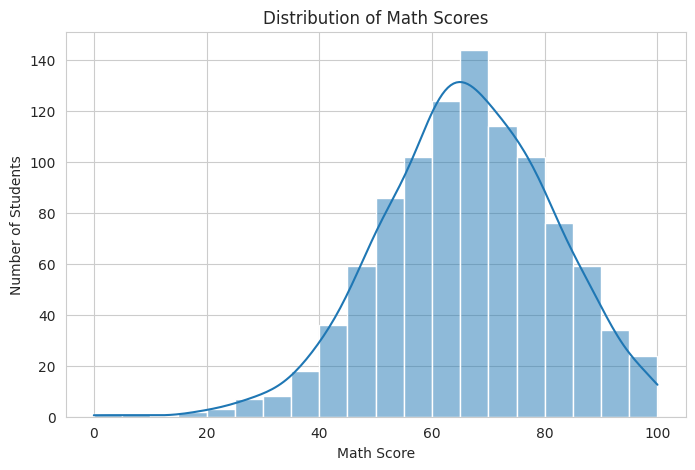

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(df['math score'], bins=20, kde=True)

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")

plt.show()

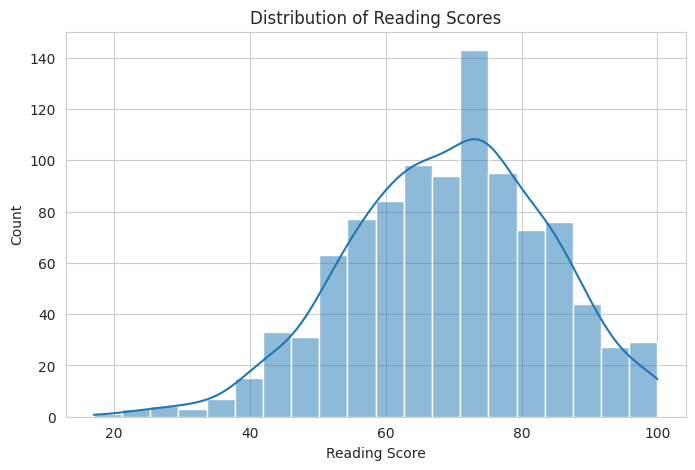

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(df['reading score'], bins=20, kde=True)

plt.title("Distribution of Reading Scores")
plt.xlabel("Reading Score")

plt.show()

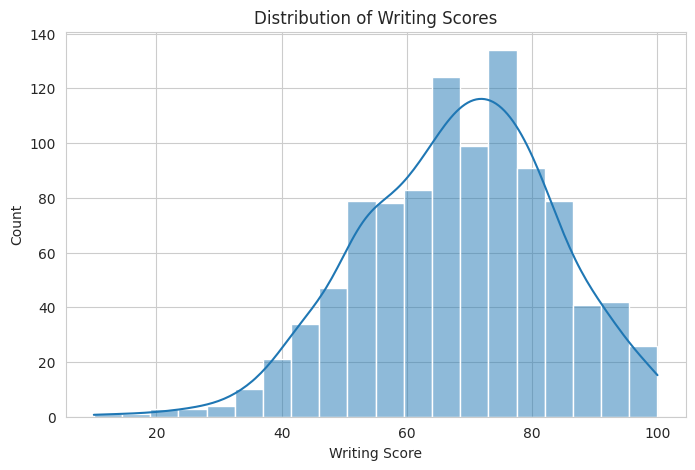

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(df['writing score'], bins=20, kde=True)

plt.title("Distribution of Writing Scores")
plt.xlabel("Writing Score")

plt.show()

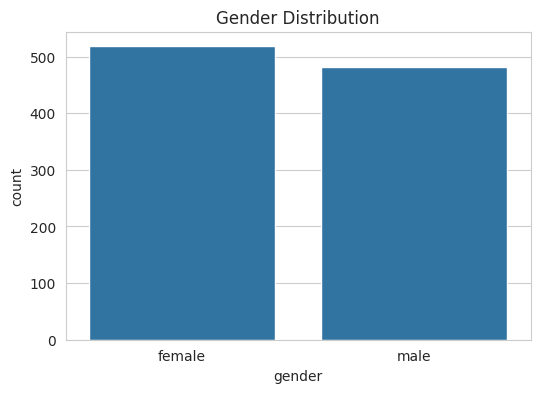

In [72]:
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")

plt.show()

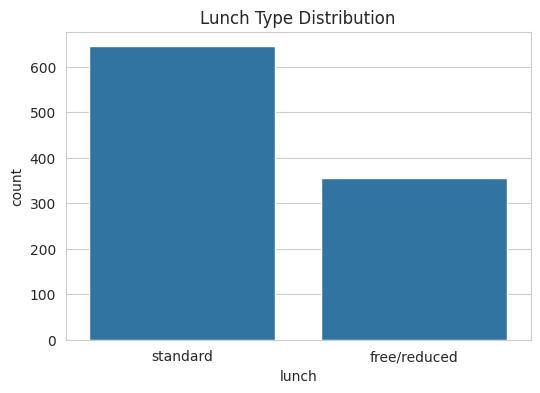

In [73]:
plt.figure(figsize=(6,4))

sns.countplot(x='lunch', data=df)

plt.title("Lunch Type Distribution")

plt.show()

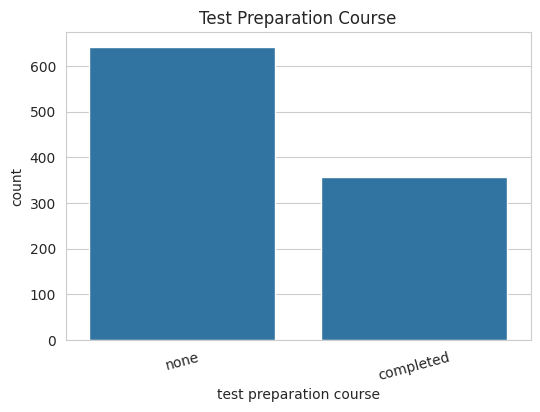

In [74]:
plt.figure(figsize=(6,4))

sns.countplot(x='test preparation course', data=df)

plt.title("Test Preparation Course")

plt.xticks(rotation=15)

plt.show()

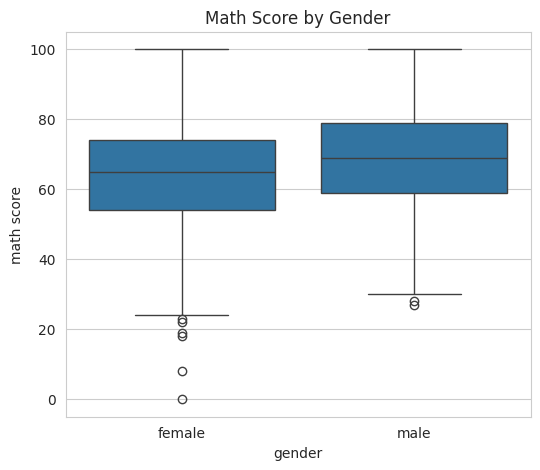

In [75]:
plt.figure(figsize=(6,5))

sns.boxplot(x='gender',
            y='math score',
            data=df)

plt.title("Math Score by Gender")

plt.show()

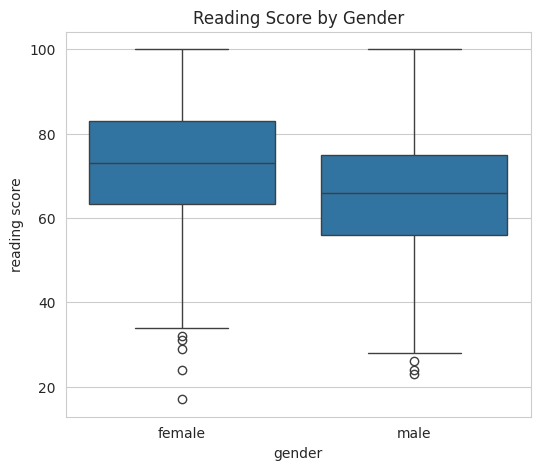

In [76]:
plt.figure(figsize=(6,5))

sns.boxplot(x='gender',
            y='reading score',
            data=df)

plt.title("Reading Score by Gender")

plt.show()

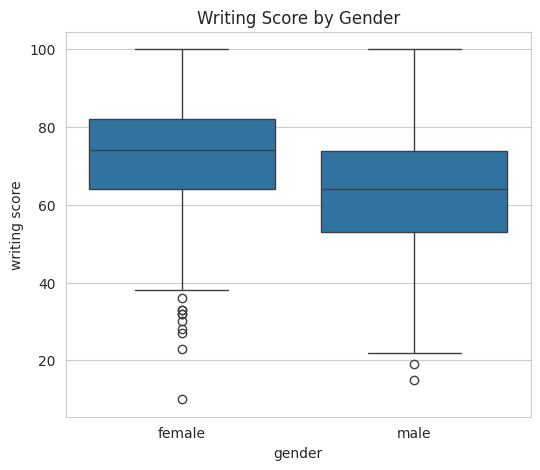

In [77]:
plt.figure(figsize=(6,5))

sns.boxplot(x='gender',
            y='writing score',
            data=df)

plt.title("Writing Score by Gender")

plt.show()

In [78]:
numeric_df = df.select_dtypes(include=['number'])

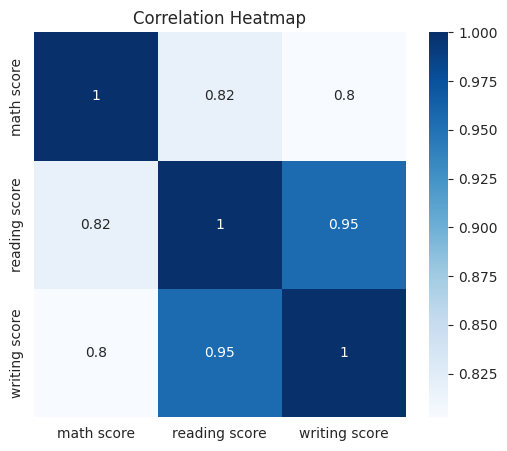

In [79]:
plt.figure(figsize=(6,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='Blues'
)

plt.title("Correlation Heatmap")

plt.show()

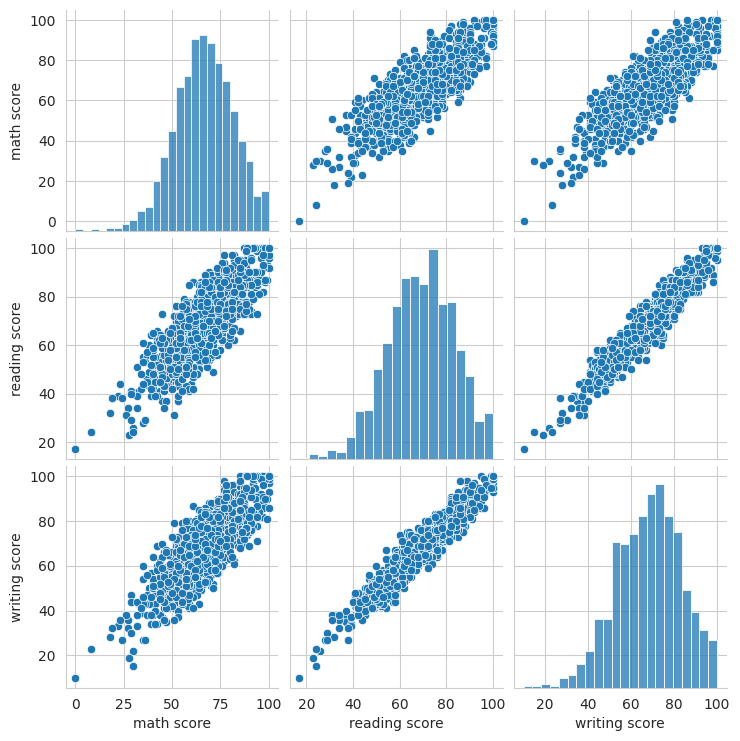

In [80]:
sns.pairplot(
    df[['math score',
        'reading score',
        'writing score']]
)

plt.show()

In [81]:
print("Average Math Score:", round(df['math score'].mean(),2))
print("Average Reading Score:", round(df['reading score'].mean(),2))
print("Average Writing Score:", round(df['writing score'].mean(),2))

Average Math Score: 66.09
Average Reading Score: 69.17
Average Writing Score: 68.05


In [82]:
X = df.drop(columns=['math score'], axis=1)
y = df['math score']

In [83]:
print(X.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  reading score  writing score  
0                    none             72             74  
1               completed             90             88  
2                    none             95             93  
3                    none             57             44  
4                    none             78             75  


In [84]:
print(y.head())

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64


In [85]:
categorical_features = X.select_dtypes(include='object').columns
numerical_features = X.select_dtypes(exclude='object').columns

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')

Numerical Features:
Index(['reading score', 'writing score'], dtype='object')


In [86]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [87]:
num_pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

In [88]:
cat_pipeline = Pipeline(
    steps=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

In [89]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        ('cat', cat_pipeline, categorical_features)
    ]
)

In [90]:
from sklearn.model_selection import train_test_split

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [92]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [93]:
print(X_train.shape)
print(X_test.shape)

(800, 19)
(200, 19)


In [94]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [95]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [96]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [97]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = mse ** 0.5

    r2 = r2_score(y_test, predictions)

    results.append([name, mae, rmse, r2])

In [98]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4.214763,5.393994,0.880433
3,Gradient Boosting,4.303784,5.576474,0.872207
2,Random Forest,4.701467,6.033663,0.850393
1,Decision Tree,6.240000,7.840918,0.747348


In [99]:
best_model = GradientBoostingRegressor(random_state=42)

best_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [100]:
predictions = best_model.predict(X_test)

In [101]:
print("MAE :", mean_absolute_error(y_test, predictions))

print("RMSE :", mean_squared_error(y_test, predictions) ** 0.5)

print("R2 Score :", r2_score(y_test, predictions))

MAE : 4.303784093112587
RMSE : 5.576473610928797
R2 Score : 0.8722065324117145


In [102]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
0,num__reading score,0.444964
1,num__writing score,0.341613
3,cat__gender_male,0.089795
2,cat__gender_female,0.065751
8,cat__race/ethnicity_group E,0.015569
15,cat__lunch_free/reduced,0.014561
16,cat__lunch_standard,0.013186
17,cat__test preparation course_completed,0.003839
18,cat__test preparation course_none,0.002064
4,cat__race/ethnicity_group A,0.001622


In [103]:
import pickle

In [104]:
with open("preprocessor.pkl", "wb") as file:
    pickle.dump(preprocessor, file)

In [105]:
with open("model.pkl", "wb") as file:
    pickle.dump(best_model, file)

In [106]:
import os

print(os.listdir())

['.config', 'model.pkl', 'preprocessor.pkl', 'StudentsPerformance.csv', 'sample_data']


In [107]:
from google.colab import files

files.download("model.pkl")
files.download("preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [108]:
import pickle

# Save the trained model
with open("model.pkl", "wb") as f:
    pickle.dump(best_model, f)

# Save the preprocessor
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print("✅ Model and preprocessor saved successfully!")

✅ Model and preprocessor saved successfully!


In [109]:
from google.colab import files

files.download("model.pkl")
files.download("preprocessor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [110]:
import numpy
import sklearn
import scipy

print("NumPy:", numpy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

NumPy: 2.0.2
Scikit-learn: 1.6.1
SciPy: 1.16.3
